# TensorBinding.jl — Real-Time Evolution

Real-time dynamics on the MPS manifold:

1. **TDVP** — Time-Dependent Variational Principle for wavefunction evolution
2. **Driven lattice** — Peierls phase (A-field), RK4 density-matrix propagation,
   and current response


In [1]:
using LinearAlgebra
using Plots
using ITensors
using ITensorMPS
include("../../src/TensorBinding.jl") # if you have the package installed, you can directly do using TensorBinding
using .TensorBinding

---
## 1. Real-time evolution via TDVP

TDVP (Time-Dependent Variational Principle) integrates the Schrodinger equation
directly on the MPS manifold, keeping the bond dimension bounded at each step.

We use `evolve_with_tdvp` from `TensorBinding.Timeev_tk` on a small 1D chain
(`L=4`, `N=16`), starting from a superposition of the two central basis states.
`compute_basis_overlaps` tracks the full probability distribution over the trajectory.


### 1a. Hamiltonian and initial state

`L=4` gives `N=16` sites — small enough to track every computational-basis overlap
explicitly. The initial state is an equal superposition of the two central sites.


In [2]:
# Small system so the MPO propagator TCI is fast
L_t  = 8
N_t  = 2^L_t

H_t     = TensorBinding.get_Hamiltonian("chain_1d", 1.0; L=L_t, scale=4.5)
sites_t = H_t.sites

# Initial state: equal superposition of the two central basis states
sitemid = N_t ÷ 2
psi0_t  = (
    TensorBinding.binary_to_MPS(sitemid,     L_t, sites_t) +
    TensorBinding.binary_to_MPS(sitemid - 1, L_t, sites_t)
) / sqrt(2)

println(H_t)
println("psi0 norm = ", real(inner(psi0_t, psi0_t)))

TBHamiltonian | L=8, N=256, scale=4.5, maxlinkdim=3 | geometry: 256 sites, 1D | no Tn cache
psi0 norm = 0.9999999999999998


### 1b. TDVP evolution and visualisation

`evolve_with_tdvp` returns the MPS at every time step.
`compute_basis_overlaps` evaluates `<x|psi(t)>` for all basis states,
returning the probability distribution as a function of site and step.
The heatmaps show quantum spreading and interference structure.


In [3]:
dt_t    = 0.01
nsteps_t = 500

tdvp_states = TensorBinding.evolve_with_tdvp(
    -1im * H_t.mpo, psi0_t, nsteps_t, dt_t;
    normalize_each_step = true,
    maxdim  = 200,
    cutoff  = 1e-10,
    nsite   = 2,
)

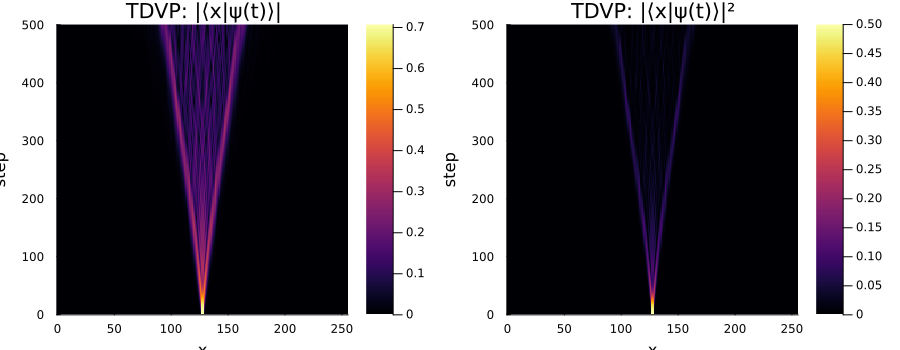

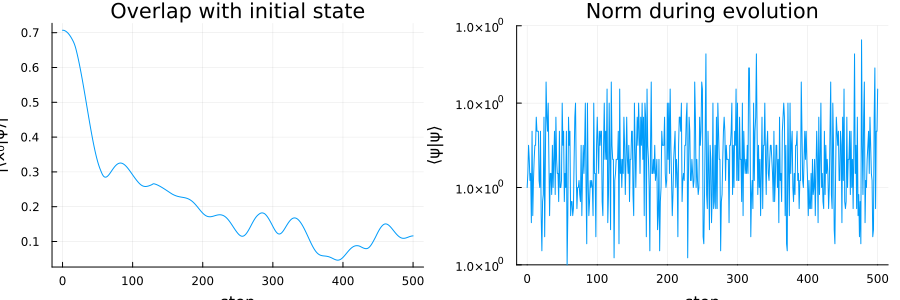

In [57]:
tdvp_data  = TensorBinding.compute_basis_overlaps(tdvp_states, L_t, sites_t)
steps_axis = 0:nsteps_t
basis_axis = 0:(N_t - 1)

p1 = heatmap(basis_axis, steps_axis, tdvp_data.abs_overlaps;
    xlabel="x", ylabel="step", title="TDVP: |⟨x|ψ(t)⟩|", color=:inferno)
p2 = heatmap(basis_axis, steps_axis, tdvp_data.probabilities;
    xlabel="x", ylabel="step", title="TDVP: |⟨x|ψ(t)⟩|²", color=:inferno)
p3 = plot(steps_axis, tdvp_data.abs_overlaps[:, sitemid];
    xlabel="step", ylabel="|⟨x₀|ψ⟩|", title="Overlap with initial state", legend=false)
p4 = plot(steps_axis, tdvp_data.norms;
    xlabel="step", ylabel="⟨ψ|ψ⟩", title="Norm during evolution", legend=false)

display(plot(p1, p2; layout=(1,2), size=(900,350)))
display(plot(p3, p4; layout=(1,2), size=(900,300)))

---
## 2. Driven square lattice — Peierls field and RK4 density-matrix evolution

The x-direction hopping picks up a time-dependent Peierls phase from an AC electric field:

$$H(t) = H_y + t_x \sum_{\langle i,j\rangle_x} \left(e^{i A_x(t)}\, c^\dagger_{i+1} c_i + \text{h.c.}\right)$$

with vector potential $A_x(t) = \frac{E_x}{\omega}\sin(\omega t)\,\Theta(t)$ turned on at $t = 0$.

The single-particle density matrix $\rho(t)$ is propagated by $\dot\rho = -i[H(t),\rho]$ using RK4.

**Efficiency trick**: decompose the Peierls phase as
$$H_x(t) = \cos(A_x)\,H_x^{\rm real} + \sin(A_x)\,H_x^{\rm imag}$$
where $H_x^{\rm real}$, $H_x^{\rm imag}$ are fixed MPOs built once — each time step is then just two scalings and two MPO additions.

In [2]:
# --- Parameters ---
Ldrv   = 6        # 2^10 = 1024 sites total
Lx_drv = 3       # 32x32 square lattice
N_drv  = 2^Ldrv

t_x    = 1.0      # x-hopping amplitude
t_y    = 1.0      # y-hopping (isotropic)
omega  = 1.0      # drive frequency
E_x    = 0.5      # drive amplitude  (A_x peak = E_x/omega)

dt_drv     = 0.1
nsteps_drv = 120  

# --- Equilibrium Hamiltonian H0 (no field) ---
H0_drv    = TensorBinding.get_Hamiltonian("square_2d", t_x;
                L=Ldrv, Lx=Lx_drv, scale=9.0)
sites_drv = H0_drv.sites

# --- Pre-build the two static Peierls MPO components ---
#
#   H_x(t) = cos(Ax) * H_x_real + sin(Ax) * H_x_imag
#
#   H_x_real = intrachain_hopping(...; t=t_x)     = t_x*(hop_fwd + hop_bwd)
#   H_x_imag = intrachain_hopping(...; t=im*t_x)  = i*t_x*(hop_fwd - hop_bwd)
#
# With Peierls:  e^{iAx}*hop_fwd + e^{-iAx}*hop_bwd
#              = cos(Ax)*(hop_fwd+hop_bwd) + i*sin(Ax)*(hop_fwd-hop_bwd)
#              = cos(Ax)*H_x_real + sin(Ax)*H_x_imag   (check: i*(hop_fwd-hop_bwd) = H_x_imag/t_x)
H_x_real = TensorBinding.intrachain_hopping(2^Lx_drv, N_drv, sites_drv; t =      t_x)
H_x_imag = TensorBinding.intrachain_hopping(2^Lx_drv, N_drv, sites_drv; t = 1im * t_x)
H_y_drv  = TensorBinding.interchain_hopping_square(2^Lx_drv, N_drv, sites_drv; t = t_y)

# --- Time-dependent Hamiltonian closure (only MPO additions at each call) ---
A_x(t)    = t > 0 ? (E_x / omega) * sin(omega * t) : 0.0

function Hoft_drv(t)
    Ax    = A_x(t)
    H_x_t = +(cos(Ax) * H_x_real, sin(Ax) * H_x_imag; cutoff=1e-10)
    return +(H_x_t, H_y_drv; cutoff=1e-10)
end

# --- Initial density matrix: zero-temperature half-filling ground state of H0 ---
rho0_drv = TensorBinding.mcweeny_purify(H0_drv;
               maxiters=50, maxdim=200, cutoff=1e-8, tol=1e-5, verbose=true)
println("Tr(rho0) = ", real(tr(rho0_drv)), "  (target: ", N_drv / 2, ")")

# --- RK4 time evolution ---
states_drv = TensorBinding.evolve_rk4_dm_timedep(
    Hoft_drv, rho0_drv, nsteps_drv, Float64(dt_drv);
    maxdim=300, cutoff=1e-10, truncate_intermediates=true, verbose=true)

McWeeny iter 15: ‖ρ²-ρ‖/‖ρ‖ = 0.12917267065943328, maxlinkdim = 15
McWeeny iter 30: ‖ρ²-ρ‖/‖ρ‖ = 0.03565343273853851, maxlinkdim = 16
McWeeny iter 45: ‖ρ²-ρ‖/‖ρ‖ = 0.000625781465927623, maxlinkdim = 16
Tr(rho0) = 28.99999461364405  (target: 32.0)
RK4 step 1 / 120,  t = 0.0,  maxlinkdim = 16
RK4 step 2 / 120,  t = 0.1,  maxlinkdim = 27
RK4 step 3 / 120,  t = 0.2,  maxlinkdim = 30
RK4 step 4 / 120,  t = 0.30000000000000004,  maxlinkdim = 32
RK4 step 5 / 120,  t = 0.4,  maxlinkdim = 32
RK4 step 6 / 120,  t = 0.5,  maxlinkdim = 33
RK4 step 7 / 120,  t = 0.6000000000000001,  maxlinkdim = 33
RK4 step 8 / 120,  t = 0.7000000000000001,  maxlinkdim = 33
RK4 step 9 / 120,  t = 0.8,  maxlinkdim = 34
RK4 step 10 / 120,  t = 0.9,  maxlinkdim = 35
RK4 step 11 / 120,  t = 1.0,  maxlinkdim = 36
RK4 step 12 / 120,  t = 1.1,  maxlinkdim = 36
RK4 step 13 / 120,  t = 1.2000000000000002,  maxlinkdim = 37
RK4 step 14 / 120,  t = 1.3,  maxlinkdim = 38
RK4 step 15 / 120,  t = 1.4000000000000001,  maxlinkdim =

121-element Vector{MPO}:
 MPO(6)
 MPO(6)
 MPO(6)
 MPO(6)
 MPO(6)
 MPO(6)
 MPO(6)
 MPO(6)
 MPO(6)
 MPO(6)
 MPO(6)
 MPO(6)
 MPO(6)
 ⋮
 MPO(6)
 MPO(6)
 MPO(6)
 MPO(6)
 MPO(6)
 MPO(6)
 MPO(6)
 MPO(6)
 MPO(6)
 MPO(6)
 MPO(6)
 MPO(6)

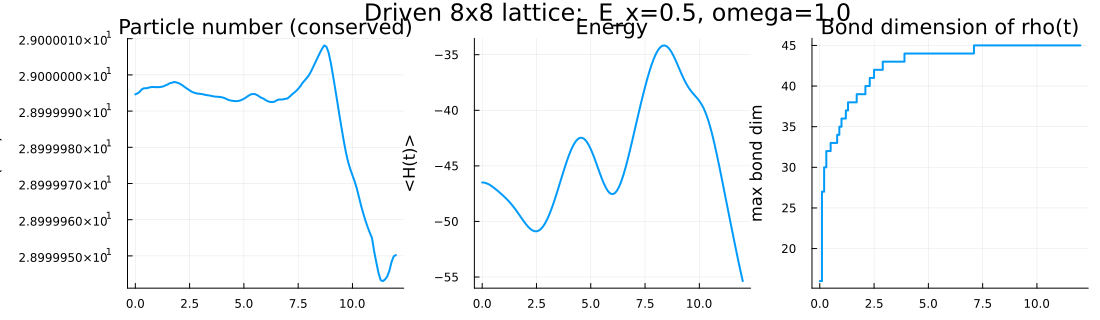

In [3]:
taxis = (0:nsteps_drv) .* dt_drv

# Particle number Tr(rho): conserved under unitary evolution — good sanity check
N_t = [real(tr(rho)) for rho in states_drv]

# Energy Tr(H(t) rho(t)): changes as the field pumps energy in
E_t = TensorBinding.timedep_observable_trajectory(
          Hoft_drv, states_drv, Float64(dt_drv))

# Bond dimension of rho(t): tracks entanglement growth
bonddim_t = [ITensorMPS.maxlinkdim(rho) for rho in states_drv]

p1 = plot(taxis, N_t;
    xlabel="t", ylabel="Tr(rho)", title="Particle number (conserved)",
    lw=2, legend=false)

p2 = plot(taxis, E_t;
    xlabel="t", ylabel="<H(t)>", title="Energy",
    lw=2, legend=false)

p3 = plot(taxis, bonddim_t;
    xlabel="t", ylabel="max bond dim", title="Bond dimension of rho(t)",
    lw=2, legend=false, seriestype=:steppost)

display(plot(p1, p2, p3; layout=(1,3), size=(1100,320),
    plot_title="Driven 8x8 lattice:  E_x=$E_x, omega=$omega"))

Central x-bond: site 30 → 31


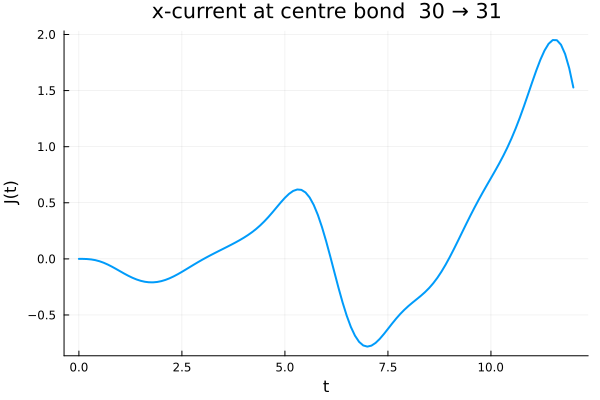

In [4]:
# --- x-current at the centre bond  J(t) = i·t_x(t)·(ρ_{j,j+1} − ρ_{j+1,j}) ---
# Peierls phase: t_x(t) = t_x * exp(i·A_x(t))

j_center = TensorBinding.central_x_bond(Ldrv; Nx=Lx_drv)
println("Central x-bond: site $j_center → $(j_center + 1)")

tx_t(t) = t_x * exp(im * A_x(t))

J_traj = TensorBinding.bond_current_x_trajectory(
    states_drv, j_center, tx_t, Ldrv, sites_drv;
    dt = Float64(dt_drv),
)

plot(taxis, real.(J_traj);
    xlabel  = "t",
    ylabel  = "J(t)",
    title   = "x-current at centre bond  $j_center → $(j_center + 1)",
    lw      = 2,
    legend  = false,
)